# ĐỒ ÁN TỐT NGHIỆP DATA SCIENCE
## Đề tài: Agoda Hotel Recommender System & Business Insights Dashboard
---
**Mục tiêu dự án:**
1. **Content-Based Filtering**: Đề xuất khách sạn tương đồng dựa trên mô tả khách sạn (sử dụng TF-IDF, Cosine Similarity và Gensim để hỗ trợ tìm kiếm tự do).
2. **Collaborative Filtering**: Gợi ý khách sạn dựa trên hành vi đánh giá của người dùng (sử dụng PySpark ALS và Scikit-Surprise SVD).
3. **Business Insights**: Phân tích sắc thái (sentiment) bình luận, thống kê nhân khẩu học khách hàng, vẽ Word Cloud từ khóa và so sánh chất lượng khách sạn với trung bình hệ thống để hỗ trợ chủ khách sạn kinh doanh tốt hơn.
4. **Streamlit Application**: Xây dựng giao diện ứng dụng demo trực quan cho cả Khách hàng và Chủ khách sạn.


In [4]:
# 1. Cài đặt các thư viện cần thiết chưa có sẵn trên Google Colab
!pip install pyvi scikit-surprise pyspark
!pip install pyvi scikit-surprise pyspark gensim

# 2. Kết nối với Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 3. Chuyển thư mục làm việc (Working Directory) đến thư mục gốc của đồ án
import os
# Lưu ý: Bạn cần đảm bảo thư mục này nằm ngay ngoài cùng của My Drive
project_path = '/content/drive/MyDrive/DL07_k314_27_phanphucloc_nguyennhattruong_ProjectAgoda'
os.chdir(project_path)
print(f"Đã chuyển thư mục làm việc đến: {os.getcwd()}")

# 4. Import các thư viện cần thiết cho đồ án
import pandas as pd
import numpy as np
import re
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Scikit-Learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error

# PyVi cho tách từ tiếng Việt
from pyvi import ViTokenizer

# Gensim
from gensim import corpora, models, similarities

# Scikit-Surprise
from surprise import Reader, Dataset, SVD
from surprise.model_selection import train_test_split as surprise_train_test_split
from surprise import accuracy

# PySpark
from pyspark.sql import SparkSession
from pyspark.ml.recommendation import ALS

import warnings
warnings.filterwarnings('ignore')
print("Đã cài đặt môi trường, map Google Drive và import thư viện thành công!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đã chuyển thư mục làm việc đến: /content/drive/MyDrive/DL07_k314_27_phanphucloc_nguyennhattruong_ProjectAgoda
Đã cài đặt môi trường, map Google Drive và import thư viện thành công!


In [5]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import re
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Scikit-Learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error

# PyVi cho tách từ tiếng Việt
from pyvi import ViTokenizer

# Gensim
from gensim import corpora, models, similarities

# Scikit-Surprise
from surprise import Reader, Dataset, SVD
from surprise.model_selection import train_test_split as surprise_train_test_split
from surprise import accuracy

# PySpark
from pyspark.sql import SparkSession
from pyspark.ml.recommendation import ALS

import warnings
warnings.filterwarnings('ignore')
print("Đã import tất cả các thư viện thành công!")


Đã import tất cả các thư viện thành công!


# 1. Tiền xử lý dữ liệu & Phân tích khám phá (EDA)
---
- **1.1 EDA**: khám phá dữ liệu thô (`hotel_info.csv`, `hotel_comments.csv`) — kích thước, kiểu dữ liệu, giá trị thiếu, phân phối điểm số — để hiểu dữ liệu trước khi xử lý.
- **1.2 Tiền xử lý**: chuẩn hóa điểm số, làm sạch & tách từ (tokenization) văn bản tiếng Việt bằng các từ điển `teencode.txt`, `emojicon.txt`, `wrong-word.txt`, `vietnamese-stopwords.txt` và `pyvi`.


## 1.1 Khám phá dữ liệu thô (EDA)

In [6]:
# Đọc dữ liệu thô, chưa qua xử lý
info_raw = pd.read_csv('data/hotel_info.csv')
comments_raw = pd.read_csv('data/hotel_comments.csv')

print(f"hotel_info.csv: {info_raw.shape[0]} dòng, {info_raw.shape[1]} cột")
print(f"hotel_comments.csv: {comments_raw.shape[0]} dòng, {comments_raw.shape[1]} cột")

info_raw.head()


hotel_info.csv: 740 dòng, 14 cột
hotel_comments.csv: 80314 dòng, 13 cột


,num,Hotel_ID,Hotel_Name,Hotel_Rank,Hotel_Address,Total_Score,Location,Cleanliness,Service,Facilities,Value_for_money,Comfort_and_room_quality,comments_count,Hotel_Description
0,1,1_1,Khách sạn Mường Thanh Luxury Nha Trang (Muong ...,5 sao trên 5,"60 Trần Phú, Lộc Thọ, Nha Trang, Việt Nam","8,8","9,4","8,9","8,9","8,7","8,7","8,3",1269,Khách sạn Mường Thanh Luxury Nha Trang - Nơi l...
1,2,1_2,ALPHA BIRD NHA TRANG,4 sao trên 5,"51/19/37 Tue Tinh St, Loc Tho Ward, Nha Trang,...","7,7","7,8","7,6","8,1","7,5","8,1",NaN,337,ALPHA BIRD NHA TRANG - Khách sạn 4.0 sao tại N...
2,3,1_3,Khách sạn Aaron (Aaron Hotel),3.5 sao trên 5,"6Trần Quang Khải, Lộc Thọ, Nha Trang, Việt Nam...","8,5","8,9","8,7","8,8","8,1","8,5",NaN,300,Khách sạn Aaron - Nơi nghỉ dưỡng tuyệt vời tại...
3,4,1_4,Panorama Star Beach Nha Trang,5 sao trên 5,"02 Nguyen Thi Minh Khai, Lộc Thọ, Nha Trang, V...","8,8","9,6","8,9","8,9","8,7","9,0",NaN,814,Panorama Star Beach Nha Trang - Một kỳ nghỉ tu...
4,5,1_5,Khách sạn Balcony Nha Trang (Balcony Nha Trang...,4 sao trên 5,"98B/13 Trần Phú, Lộc Thọ, Nha Trang, Việt Nam","8,4","8,5","8,7","8,5","8,3","8,6","8,7",294,Khách sạn Balcony Nha Trang - Nơi nghỉ dưỡng t...


In [7]:
# Kiểu dữ liệu và tỷ lệ giá trị thiếu của hotel_info
info_raw.info()
print("\nTỷ lệ giá trị thiếu (%):")
print((info_raw.isnull().mean() * 100).round(2))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   num                       740 non-null    int64 
 1   Hotel_ID                  740 non-null    object
 2   Hotel_Name                740 non-null    object
 3   Hotel_Rank                740 non-null    object
 4   Hotel_Address             740 non-null    object
 5   Total_Score               740 non-null    object
 6   Location                  413 non-null    object
 7   Cleanliness               412 non-null    object
 8   Service                   373 non-null    object
 9   Facilities                370 non-null    object
 10  Value_for_money           410 non-null    object
 11  Comfort_and_room_quality  51 non-null     object
 12  comments_count            740 non-null    int64 
 13  Hotel_Description         739 non-null    object
dtypes: int64(2), object(12)
me

Các cột điểm số (Total_Score, Location, ...) đang ở dạng chuỗi vì dùng dấu phẩy thập phân và giá trị "No information"

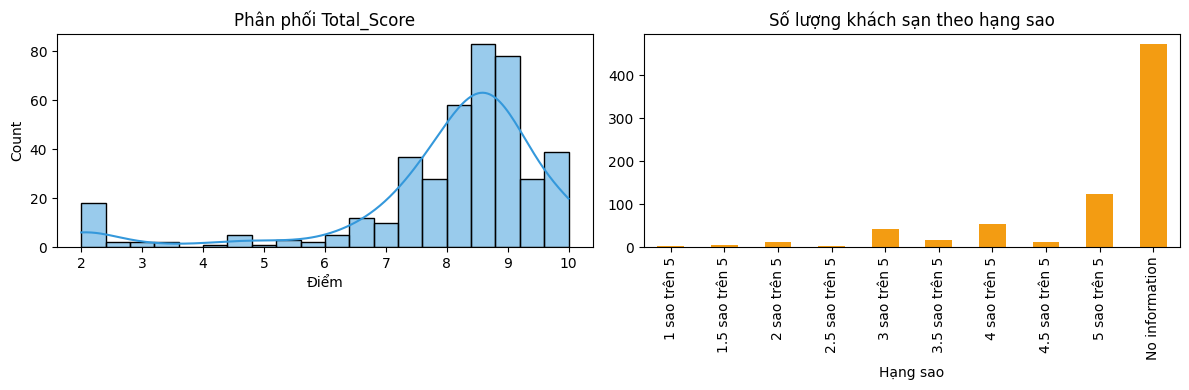

In [8]:
# Phân phối điểm đánh giá (Total_Score) và hạng sao (Hotel_Rank) của khách sạn trong hotel_info
score_preview = pd.to_numeric(
    info_raw['Total_Score'].astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(score_preview.dropna(), bins=20, kde=True, ax=axes[0], color='#3498db')
axes[0].set_title('Phân phối Total_Score')
axes[0].set_xlabel('Điểm')

info_raw['Hotel_Rank'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#f39c12')
axes[1].set_title('Số lượng khách sạn theo hạng sao')
axes[1].set_xlabel('Hạng sao')
plt.tight_layout()
plt.show()


In [9]:
# Kiểu dữ liệu và giá trị thiếu của hotel_comments
comments_raw.info()
print("\nTỷ lệ giá trị thiếu (%):")
print((comments_raw.isnull().mean() * 100).round(2))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80314 entries, 0 to 80313
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   num            80314 non-null  int64 
 1   Hotel ID       80314 non-null  object
 2   Reviewer ID    80314 non-null  object
 3   Reviewer Name  80228 non-null  object
 4   Nationality    80314 non-null  object
 5   Group Name     80314 non-null  object
 6   Room Type      80314 non-null  object
 7   Stay Details   80314 non-null  object
 8   Score          80314 non-null  object
 9   Score Level    80314 non-null  object
 10  Title          80314 non-null  object
 11  Body           80272 non-null  object
 12  Review Date    80314 non-null  object
dtypes: int64(1), object(12)
memory usage: 8.0+ MB

Tỷ lệ giá trị thiếu (%):
num              0.00
Hotel ID         0.00
Reviewer ID      0.00
Reviewer Name    0.11
Nationality      0.00
Group Name       0.00
Room Type        0.00
Stay Details   

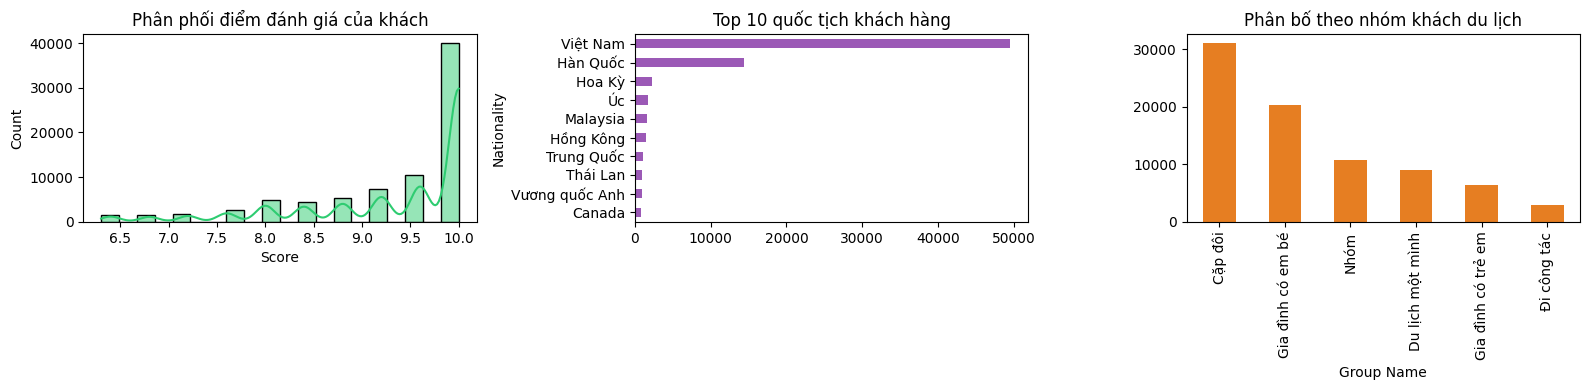

Số lượng bình luận mỗi khách sạn (trung bình): 169.8


In [10]:
# Phân phối điểm đánh giá (Score) trong các bình luận, và Top quốc tịch/nhóm khách
score_c_preview = pd.to_numeric(
    comments_raw['Score'].astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(score_c_preview.dropna(), bins=20, kde=True, ax=axes[0], color='#2ecc71')
axes[0].set_title('Phân phối điểm đánh giá của khách')

comments_raw['Nationality'].value_counts().head(10).plot(kind='barh', ax=axes[1], color='#9b59b6')
axes[1].set_title('Top 10 quốc tịch khách hàng')
axes[1].invert_yaxis()

comments_raw['Group Name'].value_counts().plot(kind='bar', ax=axes[2], color='#e67e22')
axes[2].set_title('Phân bố theo nhóm khách du lịch')
plt.tight_layout()
plt.show()

print(f"Số lượng bình luận mỗi khách sạn (trung bình): {comments_raw.groupby('Hotel ID').size().mean():.1f}")


## 1.2 Tiền xử lý dữ liệu (Data Preparation)
- Chuẩn hóa điểm số (dạng chuỗi có dấu phẩy / "No information" → số thực), điền khuyết bằng `Total_Score` hoặc trung bình cột.
- Làm sạch văn bản: chuyển thường, quy đổi emoji/teencode, loại từ sai & stop words.
- Tách từ (tokenize) tiếng Việt bằng `pyvi` để phục vụ TF-IDF/Gensim ở bước sau.


In [11]:
# Hàm tải từ điển teencode/emoji (dạng "từ<TAB>giá_trị_thay_thế")
def load_dict(filepath):
    d = {}
    if not os.path.exists(filepath):
        return d
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split('\t')
            if len(parts) == 2:
                d[parts[0]] = parts[1]
    return d

# Hàm tải danh sách từ (wrong-word / stopwords), mỗi từ một dòng
def load_word_list(filepath):
    w = set()
    if not os.path.exists(filepath):
        return w
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            word = line.strip().lower()
            if word:
                w.add(word)
    return w

# Tải các tài nguyên chuẩn hóa tiếng Việt
teencode_dict = load_dict('files/teencode.txt')
emojicon_dict = load_dict('files/emojicon.txt')
wrong_word_set = load_word_list('files/wrong-word.txt')
stopwords_set = load_word_list('files/vietnamese-stopwords.txt')
print(f"teencode: {len(teencode_dict)} mục | emoji: {len(emojicon_dict)} mục | "
      f"wrong-word: {len(wrong_word_set)} từ | stopwords: {len(stopwords_set)} từ")


teencode: 404 mục | emoji: 45 mục | wrong-word: 11842 từ | stopwords: 1950 từ


In [12]:
# Hàm làm sạch văn bản tiếng Việt: thường hóa, quy đổi emoji, bỏ HTML/ký tự đặc biệt,
# chuẩn hóa teencode, loại từ sai chính tả và stop words
def clean_vietnamese_text(text):
    if not isinstance(text, str):
        return ""
    # Chuyển về chữ thường
    text = text.lower()
    # Áp dụng từ điển emojicon
    for emoji, val in emojicon_dict.items():
        text = text.replace(emoji, " " + val + " ")
    # Loại bỏ thẻ HTML và các ký tự đặc biệt
    text = re.sub(r'<[^>]*>', ' ', text)
    text = re.sub(r'[^\w\s\d]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Áp dụng teencode và loại bỏ từ sai
    words = text.split()
    cleaned_words = []
    for w in words:
        if w in teencode_dict:
            w = teencode_dict[w]
        if w in wrong_word_set:
            continue
        cleaned_words.append(w)

    # Loại bỏ stop words
    cleaned_words = [w for w in cleaned_words if w not in stopwords_set]
    return " ".join(cleaned_words)


In [13]:
# Xử lý hotel_info: chuẩn hóa các cột điểm số và điền khuyết
info_df = pd.read_csv('data/hotel_info.csv')
print(f"Đã tải hotel_info: {info_df.shape}")

score_cols = ['Total_Score', 'Location', 'Cleanliness', 'Service', 'Facilities',
              'Value_for_money', 'Comfort_and_room_quality']
for col in score_cols:
    info_df[col] = info_df[col].astype(str).str.replace('No information', '', case=False)
    info_df[col] = info_df[col].str.replace(',', '.')
    info_df[col] = pd.to_numeric(info_df[col], errors='coerce')

# Điền khuyết các điểm chi tiết bằng Total_Score, sau đó bằng trung bình cột nếu vẫn thiếu
for col in ['Location', 'Cleanliness', 'Service', 'Facilities', 'Value_for_money', 'Comfort_and_room_quality']:
    info_df[col] = info_df[col].fillna(info_df['Total_Score'])
    info_df[col] = info_df[col].fillna(info_df[col].mean())
info_df['Total_Score'] = info_df['Total_Score'].fillna(info_df['Total_Score'].mean())

print("Đã chuẩn hóa & điền khuyết các cột điểm số.")


Đã tải hotel_info: (740, 14)
Đã chuẩn hóa & điền khuyết các cột điểm số.


In [14]:
# Làm sạch và tách từ mô tả khách sạn, rồi lưu file đã xử lý
print("Đang làm sạch và tách từ mô tả khách sạn...")
info_df['Cleaned_Description'] = info_df['Hotel_Description'].apply(clean_vietnamese_text)
info_df['Cleaned_Description_wt'] = info_df['Cleaned_Description'].apply(lambda x: ViTokenizer.tokenize(x))

info_df.to_csv('data/hotel_info_cleaned.csv', index=False, encoding='utf-8')
print("Đã lưu hotel_info_cleaned.csv!")


Đang làm sạch và tách từ mô tả khách sạn...
Đã lưu hotel_info_cleaned.csv!


In [15]:
# Xử lý hotel_comments: chuẩn hóa điểm đánh giá của khách
comments_df = pd.read_csv('data/hotel_comments.csv')
print(f"Đã tải hotel_comments: {comments_df.shape}")

comments_df['Score_Raw'] = comments_df['Score']
comments_df['Score'] = comments_df['Score'].astype(str).str.replace(',', '.').astype(float)


Đã tải hotel_comments: (80314, 13)


In [16]:
# Làm sạch và tách từ nội dung bình luận, rồi lưu file đã xử lý
print("Đang làm sạch và tách từ bình luận khách hàng (bước này mất khoảng 30-60 giây)...")
comments_df['Cleaned_Body'] = comments_df['Body'].apply(clean_vietnamese_text)
comments_df['Cleaned_Body_wt'] = comments_df['Cleaned_Body'].apply(lambda x: ViTokenizer.tokenize(x))

comments_df.to_csv('data/hotel_comments_cleaned.csv', index=False, encoding='utf-8')
print("Đã lưu hotel_comments_cleaned.csv!")


Đang làm sạch và tách từ bình luận khách hàng (bước này mất khoảng 30-60 giây)...
Đã lưu hotel_comments_cleaned.csv!


# 2. Triển khai Content-Based Filtering
---
Triển khai hai phương pháp chính:
1. **Scikit-Learn TF-IDF + Cosine Similarity**: Dùng để đề xuất các khách sạn tương đồng trực tiếp dựa trên sự giống nhau của phần mô tả khách sạn.
2. **Gensim TF-IDF + SparseMatrixSimilarity**: Dùng để hỗ trợ tìm kiếm tự do theo cụm từ khóa tự do của người dùng.


In [17]:
# Chuẩn bị dữ liệu đã làm sạch cho phần Content-Based Filtering
os.makedirs('models', exist_ok=True)

df_info = pd.read_csv('data/hotel_info_cleaned.csv')
df_info['Cleaned_Description_wt'] = df_info['Cleaned_Description_wt'].fillna("")


In [18]:
# --- Phương pháp 1: TF-IDF & Cosine Similarity (Scikit-Learn) ---
print("Huấn luyện TF-IDF & Cosine Similarity với Scikit-Learn...")
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df_info['Cleaned_Description_wt'])
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Lưu trữ mô hình để dùng lại trong app.py
with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
with open('models/cosine_sim.pkl', 'wb') as f:
    pickle.dump(cosine_sim, f)
print(f"Ma trận Cosine Similarity: {cosine_sim.shape}")


Huấn luyện TF-IDF & Cosine Similarity với Scikit-Learn...
Ma trận Cosine Similarity: (740, 740)


In [19]:
# Hàm đề xuất khách sạn tương đồng dựa trên ma trận cosine similarity
def get_recommendations(hotel_id, top_n=5):
    idx = df_info.index[df_info['Hotel_ID'] == hotel_id][0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = [s for s in sim_scores if s[0] != idx][:top_n]

    print(f"Các khách sạn tương đồng nhất với '{df_info.iloc[idx]['Hotel_Name']}':")
    for rank, (h_idx, score) in enumerate(sim_scores, 1):
        print(f"Rank {rank}: {df_info.iloc[h_idx]['Hotel_Name']} (Độ tương đồng: {score:.4f})")

# Demo với khách sạn đầu tiên trong tập dữ liệu
get_recommendations(df_info.iloc[0]['Hotel_ID'], top_n=5)


Các khách sạn tương đồng nhất với 'Khách sạn Mường Thanh Luxury Nha Trang (Muong Thanh Luxury Nha Trang Hotel)':
Rank 1: Dubai Nha Trang Hotel (Độ tương đồng: 0.8686)
Rank 2: Khách sạn Novotel Nha Trang (Novotel Nha Trang Hotel) (Độ tương đồng: 0.8627)
Rank 3: Angella Hotel Nha Trang (Độ tương đồng: 0.8578)
Rank 4: Lotus Village Nha Trang (Độ tương đồng: 0.8570)
Rank 5: Khách Sạn Vesna (Vesna Hotel) (Độ tương đồng: 0.8568)


In [20]:
# --- Phương pháp 2: Gensim TF-IDF & SparseMatrixSimilarity ---
# Dùng cho tìm kiếm tự do (free-text search) thay vì chỉ so sánh khách sạn với khách sạn
print("Huấn luyện mô hình Gensim cho tìm kiếm tự do...")
tokenized_docs = [doc.split() for doc in df_info['Cleaned_Description_wt']]
dictionary = corpora.Dictionary(tokenized_docs)
corpus = [dictionary.doc2bow(doc) for doc in tokenized_docs]
gensim_tfidf = models.TfidfModel(corpus)
gensim_index = similarities.SparseMatrixSimilarity(gensim_tfidf[corpus], num_features=len(dictionary.token2id))

# Lưu trữ mô hình để dùng lại trong app.py
with open('models/gensim_dictionary.pkl', 'wb') as f:
    pickle.dump(dictionary, f)
with open('models/gensim_tfidf.pkl', 'wb') as f:
    pickle.dump(gensim_tfidf, f)
with open('models/gensim_index.pkl', 'wb') as f:
    pickle.dump(gensim_index, f)
print(f"Kích thước từ điển Gensim: {len(dictionary)} từ")


Huấn luyện mô hình Gensim cho tìm kiếm tự do...
Kích thước từ điển Gensim: 5129 từ


In [21]:
# Hàm tìm kiếm khách sạn theo câu truy vấn tự do của người dùng
def search_hotels(query, top_n=5):
    cleaned_query = clean_vietnamese_text(query)
    query_wt = ViTokenizer.tokenize(cleaned_query).split()
    query_bow = dictionary.doc2bow(query_wt)
    sim_scores = gensim_index[gensim_tfidf[query_bow]]

    df_sim = pd.DataFrame({"id": range(len(sim_scores)), "sim": sim_scores})
    top_indices = df_sim.nlargest(top_n, 'sim')['id'].tolist()
    top_scores = df_sim.nlargest(top_n, 'sim')['sim'].tolist()

    print(f"\nKết quả tìm kiếm cho câu truy vấn '{query}':")
    for rank, (h_idx, score) in enumerate(zip(top_indices, top_scores), 1):
        if score > 0:
            print(f"Rank {rank}: {df_info.iloc[h_idx]['Hotel_Name']} (Điểm tương quan: {score:.4f})")

# Demo tìm kiếm tự do
search_hotels("khách sạn sang trọng có hồ bơi vô cực gần biển Nha Trang", top_n=5)



Kết quả tìm kiếm cho câu truy vấn 'khách sạn sang trọng có hồ bơi vô cực gần biển Nha Trang':
Rank 1: Chung cư 63 m² 2 phòng ngủ, 1 phòng tắm riêng ở Lộc Thọ (Panorama Seaview 63m2, Huge Balcony, Pools & Gym) (Điểm tương quan: 0.2922)
Rank 2: Căn hộ 45 m² 1 phòng ngủ, 1 phòng tắm riêng ở Vĩnh Hải (Luxury apartment with sea and city view) (Điểm tương quan: 0.2819)
Rank 3: Căn hộ 36 m² 1 phòng ngủ, 1 phòng tắm riêng ở Biển Bãi Dài (The Empyrean Cam Ranh Beach resort) (Điểm tương quan: 0.2802)
Rank 4: Căn hộ studio 40 m² có 1 phòng tắm riêng ở Lộc Thọ (City View | Bathtub | Paranoma) (Điểm tương quan: 0.2759)
Rank 5: Căn hộ studio 40 m² có 1 phòng tắm riêng ở Lộc Thọ (Sea View | Bathtub ) (Điểm tương quan: 0.2759)


# 3. Triển khai Collaborative Filtering
---
Hệ thống sẽ được triển khai theo 2 mô hình chính để đối chứng:
1. **Scikit-Surprise SVD**: Mô hình Matrix Factorization truyền thống trên Python.
2. **PySpark ALS**: Mô hình Matrix Factorization trên nền tảng Big Data Spark.

Do mỗi reviewer chỉ đánh giá đúng 1 khách sạn (sparsity cực cao), chúng ta sẽ huấn luyện và đánh giá RMSE bằng cách sử dụng điểm trung bình làm fallback khi gặp người dùng mới (cold start).


In [22]:
df_comments = pd.read_csv('data/hotel_comments_cleaned.csv')


In [23]:
# --- Mô hình 1: Scikit-Surprise SVD ---
print("1. Huấn luyện Surprise SVD...")
reader = Reader(rating_scale=(1.0, 10.0))
data = Dataset.load_from_df(df_comments[['Reviewer ID', 'Hotel ID', 'Score']], reader)

trainset, testset = surprise_train_test_split(data, test_size=0.2, random_state=42)
svd = SVD(n_factors=50, random_state=42)
svd.fit(trainset)

predictions = svd.test(testset)
svd_rmse = accuracy.rmse(predictions)


1. Huấn luyện Surprise SVD...
RMSE: 0.9213


In [24]:
# Train lại trên toàn bộ tập dữ liệu (không tách test) để dùng cho deploy
full_trainset = data.build_full_trainset()
svd_full = SVD(n_factors=50, random_state=42)
svd_full.fit(full_trainset)

with open('models/surprise_svd.pkl', 'wb') as f:
    pickle.dump(svd_full, f)
print("Đã lưu mô hình Surprise SVD.")


Đã lưu mô hình Surprise SVD.


In [25]:
# --- Mô hình 2: PySpark ALS ---
# Bước 1: khởi tạo SparkSession và tạo ánh xạ ID (reviewer/hotel) sang số nguyên,
# vì ALS yêu cầu userCol/itemCol là kiểu số nguyên
print("2. Khởi chạy SparkSession để huấn luyện ALS...")
spark = SparkSession.builder \
    .appName("AgodaALS") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.warehouse.dir", "file:///C:/temp") \
    .getOrCreate()

reviewers = df_comments['Reviewer ID'].unique()
hotels = df_comments['Hotel ID'].unique()

reviewer_to_idx = {rid: i for i, rid in enumerate(reviewers)}
hotel_to_idx = {hid: i for i, hid in enumerate(hotels)}
idx_to_hotel = {i: hid for i, hid in enumerate(hotels)}

with open('models/cf_mappings.pkl', 'wb') as f:
    pickle.dump({
        'reviewer_to_idx': reviewer_to_idx,
        'hotel_to_idx': hotel_to_idx,
        'idx_to_hotel': idx_to_hotel
    }, f)


2. Khởi chạy SparkSession để huấn luyện ALS...


In [26]:
# Bước 2: chuyển dữ liệu sang Spark DataFrame và huấn luyện ALS
try:
    df_mapped = df_comments[['Reviewer ID', 'Hotel ID', 'Score']].copy()
    df_mapped['user_idx'] = df_mapped['Reviewer ID'].map(reviewer_to_idx)
    df_mapped['item_idx'] = df_mapped['Hotel ID'].map(hotel_to_idx)

    spark_df = spark.createDataFrame(df_mapped[['user_idx', 'item_idx', 'Score']].dropna())
    spark_df = spark_df.withColumnRenamed("user_idx", "user") \
                       .withColumnRenamed("item_idx", "item") \
                       .withColumnRenamed("Score", "rating")

    training_df, test_df = spark_df.randomSplit([0.8, 0.2], seed=42)

    # coldStartStrategy='nan' để tránh lỗi khi tập test có user/item không xuất hiện trong tập train
    als = ALS(maxIter=10, regParam=0.1, userCol="user", itemCol="item", ratingCol="rating",
              coldStartStrategy="nan", nonnegative=True)
    model = als.fit(training_df)

    # Predict và đánh giá RMSE (chuyển sang Pandas để tính bằng sklearn cho tiện)
    predictions_spark = model.transform(test_df)
    pred_pd = predictions_spark.toPandas()

    # Điền khuyết dự báo NaN (cold-start) bằng điểm trung bình hệ thống
    global_mean = df_mapped['Score'].mean()
    pred_pd['prediction'] = pred_pd['prediction'].fillna(global_mean)

    als_rmse = np.sqrt(mean_squared_error(pred_pd['rating'], pred_pd['prediction']))
    print(f"PySpark ALS Test RMSE: {als_rmse:.4f}")

    # Trích xuất user và item factors để tích hợp lên Streamlit mà không cần khởi động lại Spark
    user_factors = model.userFactors.toPandas()
    item_factors = model.itemFactors.toPandas()

    user_factors.to_pickle('models/als_user_factors.pkl')
    item_factors.to_pickle('models/als_item_factors.pkl')
    print("Đã trích xuất và lưu trữ các ALS factors thành công.")

finally:
    spark.stop()
    print("Đã đóng Spark Session.")


PySpark ALS Test RMSE: 0.9407
Đã trích xuất và lưu trữ các ALS factors thành công.
Đã đóng Spark Session.


In [27]:
# So sánh kết quả giữa 2 phương pháp Collaborative Filtering
print("=== Tóm tắt kết quả Collaborative Filtering ===")
print(f"Surprise SVD RMSE: {svd_rmse:.4f}")
print(f"PySpark ALS RMSE: {als_rmse:.4f}")


=== Tóm tắt kết quả Collaborative Filtering ===
Surprise SVD RMSE: 0.9213
PySpark ALS RMSE: 0.9407


# 4. Phân tích phản hồi khách hàng & Cung cấp Business Insights
---
Trong phần này, sẽ:
- Tính toán điểm trung bình toàn hệ thống của Agoda cho từng tiêu chí (`Location`, `Cleanliness`, `Service`, etc.) để so sánh đối chứng.
- Phân tích sắc thái nhận xét (Sentiment) dựa trên điểm số đánh giá (`Score >= 8.0`: Tích cực, `Score < 6.0`: Tiêu cực, còn lại: Trung lập).
- Thống kê nhân khẩu học khách hàng (Quốc tịch, hình thức đi du lịch) cho từng khách sạn.
- Chiết xuất các từ khóa đặc trưng nhất trong các nhận xét tích cực và tiêu cực (sau khi loại bỏ stop words).
- Lưu trữ toàn bộ kết quả tổng hợp này để làm Dashboard Streamlit tải cực nhanh.


In [28]:
df_info = pd.read_csv('data/hotel_info_cleaned.csv')
df_comments = pd.read_csv('data/hotel_comments_cleaned.csv')

# 1. Điểm trung bình toàn hệ thống cho từng tiêu chí, dùng làm mốc so sánh cho mỗi khách sạn
sub_scores = ['Location', 'Cleanliness', 'Service', 'Facilities', 'Value_for_money', 'Comfort_and_room_quality']
system_averages = df_info[sub_scores].mean().to_dict()


In [29]:
# 2. Trích xuất tháng-năm từ Review Date (dạng "... tháng X, YYYY") và gán nhãn sắc thái
def parse_date(date_str):
    if not isinstance(date_str, str):
        return None
    year_match = re.search(r'\b(20\d{2})\b', date_str)
    month_match = re.search(r'tháng\s+(\d+)', date_str)
    if year_match and month_match:
        return f"{year_match.group(1)}-{int(month_match.group(1)):02d}"
    return None

df_comments['Year_Month'] = df_comments['Review Date'].apply(parse_date)

score_level_to_sentiment = {
    'Hài Lòng': 'Negative',
    'Rất tốt': 'Neutral',
    'Tuyệt vời': 'Positive',
    'Trên cả tuyệt vời': 'Positive',
}
df_comments['Sentiment'] = df_comments['Score Level'].map(score_level_to_sentiment).fillna('Neutral')
df_comments['Sentiment'].value_counts()


,count
Sentiment,
Positive,72865
Neutral,4356
Negative,3093


Note: cột Score trong bộ dữ liệu này không bao giờ thấp hơn 6.3 (có vẻ Agoda đã lọc bỏ các đánh giá quá tệ trước khi xuất dữ liệu), nên ngưỡng "Score < 6.0" cho nhãn Negative sẽ KHÔNG BAO GIỜ được kích hoạt -> mọi khách sạn sẽ hiện 0% tiêu cực một cách sai lệch. Thay vào đó, dùng đúng cột 'Score Level' do Agoda tự phân loại (phản ánh đúng các mức thực sự tồn tại trong dữ liệu) để gán nhãn sắc thái.

In [30]:
# 3. Bổ sung stopwords đặc thù cho bài toán, để chúng không lấn át các từ khóa thực sự
# đặc trưng khi thống kê tần suất. Bình luận trong dữ liệu này đa ngôn ngữ (Việt/Anh/Pháp/...),
# nhưng vietnamese-stopwords.txt chỉ phủ tiếng Việt, nên trước đây các từ khóa nổi bật toàn
# là từ chức năng tiếng Anh vô nghĩa (was, with, are, is, the, which, ...). Bổ sung danh sách
# stopword tiếng Anh/Pháp/Đức khá đầy đủ, và chỉ giữ token thuộc bảng chữ Latin/Việt (loại
# fragment tiếng Ả Rập/Trung/Nga lẫn vào).
custom_stopwords = {'khách_sạn', 'phòng', 'ở', 'ks', 'hotel', 'mình', 'có', 'và', 'là', 'được',
                     'nha_trang', 'muong_thanh', 'mường_thanh',
                     # 'không' (phủ định) và 'sạn'/'tâm'/'hơi' (fragment còn sót lại của từ ghép
                     # không nối được, vd "sạn" từ "khách_sạn") không mang tín hiệu gì khi đứng riêng
                     'không', 'sạn', 'tâm', 'hơi'}

english_stopwords = {
    'a', 'about', 'above', 'after', 'again', 'all', 'am', 'an', 'and', 'any', 'are', "aren't",
    'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but',
    'by', 'can', "can't", 'cannot', 'could', "couldn't", 'did', "didn't", 'do', 'does',
    "doesn't", 'doing', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further',
    'had', "hadn't", 'has', "hasn't", 'have', "haven't", 'having', 'he', "he'd", "he'll",
    "he's", 'her', 'here', "here's", 'hers', 'herself', 'him', 'himself', 'his', 'how',
    "how's", 'i', "i'd", "i'll", "i'm", "i've", 'if', 'in', 'into', 'is', "isn't", 'it',
    "it's", 'its', 'itself', "let's", 'me', 'more', 'most', "mustn't", 'my', 'myself', 'no',
    'nor', 'not', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'ought', 'our', 'ours',
    'ourselves', 'out', 'over', 'own', 'same', "shan't", 'she', "she'd", "she'll", "she's",
    'should', "shouldn't", 'so', 'some', 'such', 'than', 'that', "that's", 'the', 'their',
    'theirs', 'them', 'themselves', 'then', 'there', "there's", 'these', 'they', "they'd",
    "they'll", "they're", "they've", 'this', 'those', 'through', 'to', 'too', 'under', 'until',
    'up', 'very', 'was', "wasn't", 'we', "we'd", "we'll", "we're", "we've", 'were', "weren't",
    'what', "what's", 'when', "when's", 'where', "where's", 'which', 'while', 'who', "who's",
    'whom', 'why', "why's", 'with', "won't", 'would', "wouldn't", 'you', "you'd", "you'll",
    "you're", "you've", 'your', 'yours', 'yourself', 'yourselves', 'just', 'also', 'really',
    'previously', 'ready', 'provide', 'meet', 'different', 'compare', 'valuable', 'stayed',
    'surprisingly', 'will', 'shall', 'get', 'got', 'one', 'two', 'us', 'however', 'spacious',
}
other_lang_stopwords = {
    'die', 'der', 'und', 'das', 'sehr', 'ist', 'ein', 'eine',
    'le', 'la', 'les', 'un', 'une', 'des', 'de', 'du', 'et', 'est', 'en', 'que', 'qui',
    'nous', 'vous', 'ils', 'elles', 'très', 'avons', 'sont', 'avec', 'pour', 'dans', 'pas',
    'plus', 'ce', 'cette', 'au', 'aux', 'notre', 'votre',
}
stopwords_set.update(custom_stopwords | english_stopwords | other_lang_stopwords)

# NOTE: một danh sách ký tự tường minh, KHÔNG dùng dải mã kiểu "à-ỹ" - dải đó trải từ U+00E0
# đến U+1EF9, mà xét theo số thứ tự Unicode thì dải này bao trùm luôn toàn bộ khối Cyrillic
# và Hy Lạp (chữ Việt có dấu không nằm liên tục trong Unicode), nên trước đây vẫn lọt fragment
# tiếng Nga/Hy Lạp vào. Từ đã .lower() sẵn nên cũng không cần cờ IGNORECASE.
_vn_chars = "aàáảãạăằắẳẵặâầấẩẫậbcdđeèéẻẽẹêềếểễệfghiìíỉĩịjklmnoòóỏõọôồốổỗộơờớởỡợpqrstuùúủũụưừứửữựvwxyỳýỷỹỵz_"
latin_vn_re = re.compile(f'^[{_vn_chars}]+$')

def hotel_name_tokens(hotel_name):
    # để tên thương hiệu khách sạn (vd: "Sata") không lấn át các từ khóa mô tả thực sự
    cleaned = re.sub(r'[^\w\s]', ' ', str(hotel_name).lower())
    return {re.sub(r'\s+', '_', t.strip()) for t in cleaned.split() if t.strip()}

name_by_id = df_info.set_index('Hotel_ID')['Hotel_Name'].to_dict()

# Hàm lấy top-N từ khóa nổi bật, có loại số/token quá ngắn/ngôn ngữ khác, và loại từ chỉ
# xuất hiện đúng 1 lần (tránh các fragment ngoại ngữ hiếm lấn át từ khóa lặp lại thật sự)
def get_keywords(texts, exclude_words, top_n=30, min_count=2):
    words = []
    for t in texts:
        for w in t.split():
            wl = w.lower().strip()
            if not wl or wl in stopwords_set or wl in exclude_words:
                continue
            if len(wl.replace('_', '')) < 3:
                continue
            if not latin_vn_re.match(wl):
                continue
            words.append(wl)
    counts = Counter(words)
    filtered = {w: c for w, c in counts.items() if c >= min_count}
    if not filtered and counts:
        filtered = dict(counts.most_common(top_n))
    return dict(Counter(filtered).most_common(top_n))


In [31]:
# 4. Tổng hợp insight cho từng khách sạn: sắc thái, nhân khẩu học, xu hướng theo thời gian, từ khóa
print("Đang tổng hợp dữ liệu insights cho từng khách sạn...")
hotel_insights = {}
grouped = df_comments.groupby('Hotel ID')

for hotel_id, group in grouped:
    total = len(group)

    # Sắc thái bình luận
    sent_counts = group['Sentiment'].value_counts().to_dict()
    sent_pct = {k: (v / total) * 100 for k, v in sent_counts.items()}

    # Quốc tịch & Hình thức đi du lịch
    nationality_dist = group['Nationality'].value_counts().head(5).to_dict()
    group_dist = group['Group Name'].value_counts().to_dict()

    # Xu hướng đánh giá theo thời gian (12 tháng gần nhất)
    trend = group['Year_Month'].value_counts().sort_index().tail(12).to_dict()

    # Từ khóa nổi bật trong bình luận Tích cực/Tiêu cực
    pos_texts = group[group['Sentiment'] == 'Positive']['Cleaned_Body_wt'].dropna().tolist()
    neg_texts = group[group['Sentiment'] == 'Negative']['Cleaned_Body_wt'].dropna().tolist()

    exclude_words = hotel_name_tokens(name_by_id.get(hotel_id, ""))
    pos_keywords = get_keywords(pos_texts, exclude_words)
    neg_keywords = get_keywords(neg_texts, exclude_words)

    hotel_insights[hotel_id] = {
        'total_comments': total,
        'sentiment_counts': sent_counts,
        'sentiment_pct': sent_pct,
        'nationality_dist': nationality_dist,
        'group_dist': group_dist,
        'trend': trend,
        'pos_keywords': pos_keywords,
        'neg_keywords': neg_keywords
    }


Đang tổng hợp dữ liệu insights cho từng khách sạn...


In [32]:
# Lưu toàn bộ insight đã tổng hợp để Streamlit app đọc trực tiếp, không cần tính lại
insights_data = {
    'system_averages': system_averages,
    'hotel_insights': hotel_insights
}

with open('models/hotel_insights.pkl', 'wb') as f:
    pickle.dump(insights_data, f)
print(f"Đã tổng hợp và lưu thành công dữ liệu insights cho {len(hotel_insights)} khách sạn!")


Đã tổng hợp và lưu thành công dữ liệu insights cho 473 khách sạn!


### Trực quan hóa thử nghiệm một số Insights của khách sạn đầu tiên (Mường Thanh Nha Trang)
Dưới đây là một số thống kê nhanh:


Khách sạn: Khách sạn Mường Thanh Luxury Nha Trang (Muong Thanh Luxury Nha Trang Hotel)
Tổng số bình luận: 1269
Tỷ lệ sắc thái bình luận: {'Positive': 92.75019700551616, 'Neutral': 4.25531914893617, 'Negative': 2.9944838455476757}


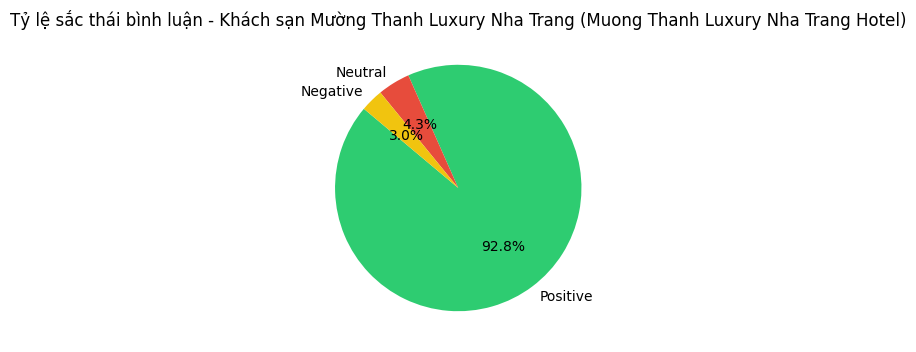

In [33]:
hotel_id = df_info.iloc[0]['Hotel_ID']
hotel_name = df_info.iloc[0]['Hotel_Name']
insight = hotel_insights.get(hotel_id, {})

print(f"Khách sạn: {hotel_name}")
print(f"Tổng số bình luận: {insight.get('total_comments')}")
print("Tỷ lệ sắc thái bình luận:", insight.get('sentiment_pct'))

# Vẽ biểu đồ sắc thái tròn
pcts = insight.get('sentiment_pct', {})
labels = list(pcts.keys())
sizes = list(pcts.values())

if sizes:
    plt.figure(figsize=(6, 4))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#2ecc71', '#e74c3c', '#f1c40f'])
    plt.title(f"Tỷ lệ sắc thái bình luận - {hotel_name}")
    plt.show()


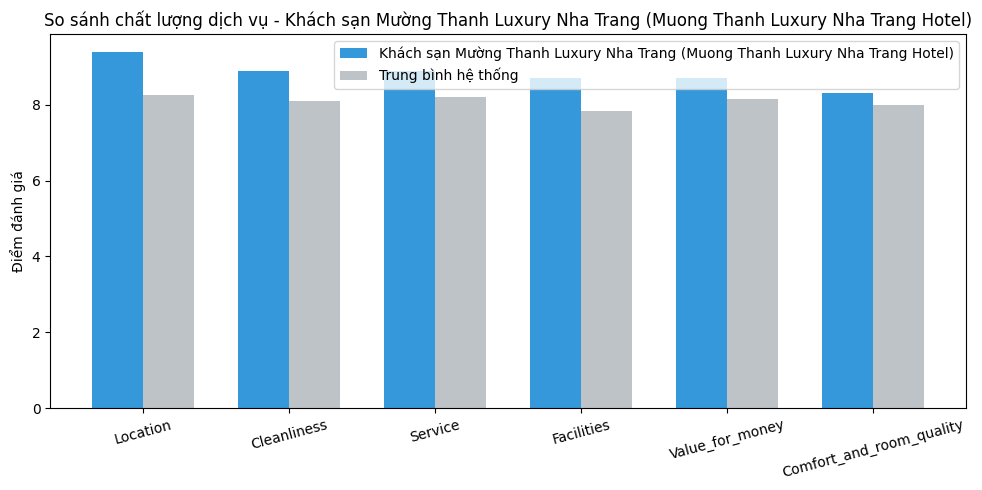

In [34]:
# Vẽ biểu đồ so sánh điểm từng tiêu chí của khách sạn với trung bình hệ thống
hotel_scores = df_info.iloc[0][sub_scores].to_dict()
categories = list(hotel_scores.keys())
h_vals = list(hotel_scores.values())
sys_vals = [system_averages[c] for c in categories]

x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, h_vals, width, label=hotel_name, color='#3498db')
plt.bar(x + width/2, sys_vals, width, label='Trung bình hệ thống', color='#bdc3c7')
plt.xticks(x, categories, rotation=15)
plt.ylabel('Điểm đánh giá')
plt.title(f"So sánh chất lượng dịch vụ - {hotel_name}")
plt.legend()
plt.tight_layout()
plt.show()


# KẾT LUẬN
---
Notebook này đã xây dựng xong các mô hình chính:
1. **Content-Based Filtering** (TF-IDF + Cosine Similarity & Gensim).
2. **Collaborative Filtering** (Surprise SVD & PySpark ALS).
3. **Business Insights & Sentiment Analysis**.

Tất cả các mô hình, ánh xạ và dữ liệu insights đã được xuất dưới dạng file pickle trong thư mục `models/`.